<a href="https://colab.research.google.com/github/SachinnChoudhary/waste2worth/blob/main/Waste2Worth_Matching_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waste2Worth — Buyer-Industry Matching Model

**Task:** Given a waste listing and a candidate buyer company, predict whether it is a good
match (`is_match`) — i.e., a binary classification / recommendation-scoring problem.

**Dataset:** `training_pairs.csv` (synthetic, 600 waste listings × 42 buyer companies = 25,200 pairs).
See the accompanying `README.md` for the full data dictionary and label-generation methodology.

**Notebook contents**
1. Setup & data loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing pipeline
4. Train/test split
5. Baseline model — Logistic Regression
6. Random Forest model
7. Model comparison & evaluation (ROC, PR curve, confusion matrix)
8. Feature importance
9. Save the trained model


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)

df = pd.read_csv("/content/training_pairs.csv")
print("Shape:", df.shape)
df.head()


Shape: (25200, 22)


,waste_id,buyer_id,waste_category,waste_subcategory,waste_hazard_level,waste_hazard_ordinal,waste_quantity_tons,waste_condition,waste_purity_pct,waste_moisture_pct,waste_price_expectation_per_ton_inr,waste_zone,buyer_industry_sector,buyer_hazard_tolerance_ordinal,buyer_min_quantity_tons,buyer_min_purity_pct_required,buyer_company_size,buyer_zone,same_zone,category_accepted,match_score,is_match
0,WST-00001,BUY-0001,Glass Waste,Glass Cullet,Low,1,8.86,Mixed,50.7,NaN,2412.0,West,Metal Foundry & Casting,0,47.89,56,Large,South,0,0,20.7,0
1,WST-00001,BUY-0002,Glass Waste,Glass Cullet,Low,1,8.86,Mixed,50.7,NaN,2412.0,West,Metal Foundry & Casting,2,38.02,65,Large,West,1,0,34.8,0
2,WST-00001,BUY-0003,Glass Waste,Glass Cullet,Low,1,8.86,Mixed,50.7,NaN,2412.0,West,Metal Foundry & Casting,1,37.74,59,Large,West,1,0,34.1,0
3,WST-00001,BUY-0004,Glass Waste,Glass Cullet,Low,1,8.86,Mixed,50.7,NaN,2412.0,West,Automotive Manufacturing,1,4.31,74,Small,West,1,0,54.2,0
4,WST-00001,BUY-0005,Glass Waste,Glass Cullet,Low,1,8.86,Mixed,50.7,NaN,2412.0,West,Automotive Manufacturing,1,27.79,69,Large,South,0,0,25.4,0


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25200 entries, 0 to 25199
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   waste_id                             25200 non-null  object 
 1   buyer_id                             25200 non-null  object 
 2   waste_category                       25200 non-null  object 
 3   waste_subcategory                    25200 non-null  object 
 4   waste_hazard_level                   25200 non-null  object 
 5   waste_hazard_ordinal                 25200 non-null  int64  
 6   waste_quantity_tons                  25200 non-null  float64
 7   waste_condition                      25200 non-null  object 
 8   waste_purity_pct                     15036 non-null  float64
 9   waste_moisture_pct                   4662 non-null   float64
 10  waste_price_expectation_per_ton_inr  25200 non-null  float64
 11  waste_zone                  

In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
waste_id,25200,600,WST-00001,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
buyer_id,25200,42,BUY-0001,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
waste_category,25200,11,Plastic Waste,2856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
waste_subcategory,25200,43,Glass Cullet,1176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
waste_hazard_level,25200,4,Non-hazardous,14532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
waste_hazard_ordinal,25200.0,NaN,NaN,NaN,0.655,0.888448,0.0,0.0,0.0,1.0,3.0
waste_quantity_tons,25200.0,NaN,NaN,NaN,11.762533,8.50523,0.81,5.6875,9.9,15.37,60.86
waste_condition,25200,4,Clean & Sorted,10374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
waste_purity_pct,15036.0,NaN,NaN,NaN,71.44581,15.552992,45.1,57.8,72.05,85.5,99.0
waste_moisture_pct,4662.0,NaN,NaN,NaN,23.555856,10.660756,5.5,14.2,24.4,32.5,40.0


## 2. Exploratory Data Analysis

### 2.1 Target class balance
The target `is_match` is imbalanced (most waste-buyer pairs are *not* a good fit) —
this mirrors real-world matching/recommendation problems.


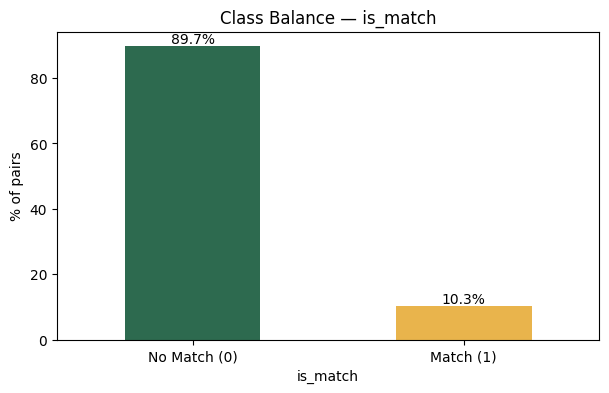

is_match
0    22614
1     2586
Name: count, dtype: int64


In [3]:
class_counts = df["is_match"].value_counts(normalize=True) * 100
ax = class_counts.plot(kind="bar", color=["#2D6A4F", "#E9B44C"])
ax.set_xticklabels(["No Match (0)", "Match (1)"], rotation=0)
ax.set_ylabel("% of pairs")
ax.set_title("Class Balance — is_match")
for i, v in enumerate(class_counts):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.show()

print(df["is_match"].value_counts())


### 2.2 Waste category distribution

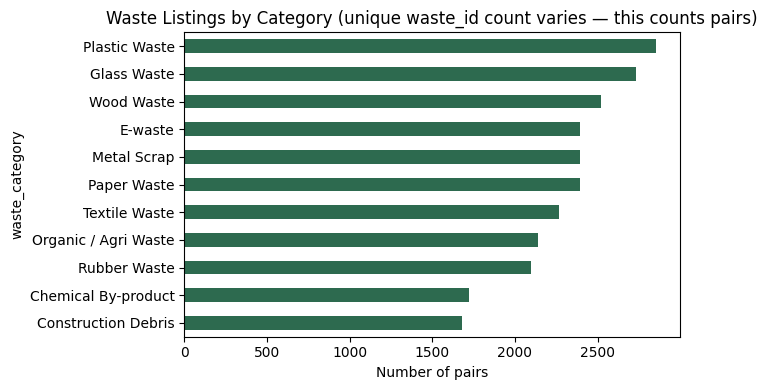

In [4]:
df["waste_category"].value_counts().sort_values().plot(kind="barh", color="#2D6A4F")
plt.title("Waste Listings by Category (unique waste_id count varies — this counts pairs)")
plt.xlabel("Number of pairs")
plt.tight_layout()
plt.show()


### 2.3 Match rate by waste category
Which waste categories tend to find more buyer matches?

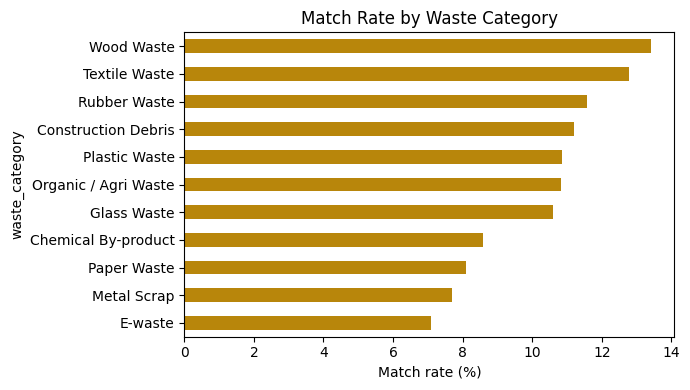

In [5]:
match_rate_by_cat = df.groupby("waste_category")["is_match"].mean().sort_values() * 100
match_rate_by_cat.plot(kind="barh", color="#B8860B")
plt.xlabel("Match rate (%)")
plt.title("Match Rate by Waste Category")
plt.tight_layout()
plt.show()


### 2.4 Match rate by same-zone vs cross-zone
Does geography (same region) affect match likelihood?

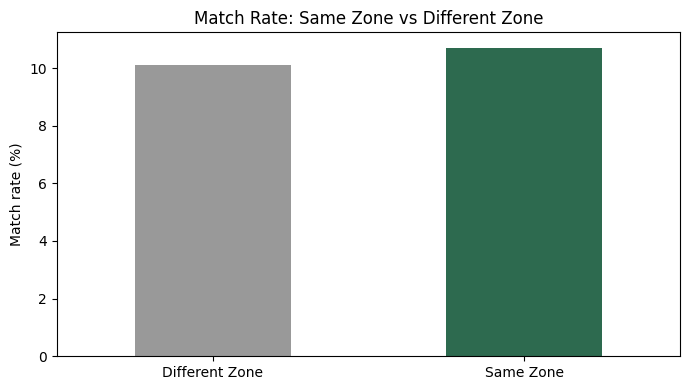

In [6]:
zone_match = df.groupby("same_zone")["is_match"].mean() * 100
zone_match.index = ["Different Zone", "Same Zone"]
zone_match.plot(kind="bar", color=["#999999", "#2D6A4F"])
plt.ylabel("Match rate (%)")
plt.title("Match Rate: Same Zone vs Different Zone")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 2.5 Match score distribution by outcome
Sanity check — matched pairs should generally have a higher `match_score`.

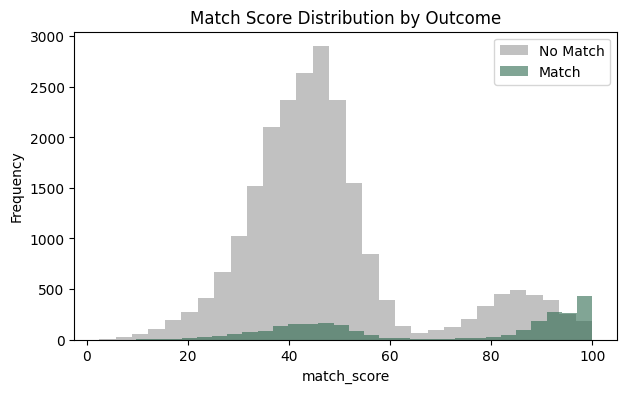

In [7]:
fig, ax = plt.subplots()
df[df.is_match == 0]["match_score"].plot(kind="hist", bins=30, alpha=0.6, label="No Match", ax=ax, color="#999999")
df[df.is_match == 1]["match_score"].plot(kind="hist", bins=30, alpha=0.6, label="Match", ax=ax, color="#2D6A4F")
ax.set_xlabel("match_score")
ax.set_title("Match Score Distribution by Outcome")
ax.legend()
plt.show()


### 2.6 Missing values
`waste_purity_pct` and `waste_moisture_pct` are only relevant for certain waste categories, so nulls are expected.

In [8]:
missing = df.isna().sum()
missing[missing > 0]


,0
waste_purity_pct,10164
waste_moisture_pct,20538


## 3. Preprocessing Pipeline

- **Numeric columns**: median-impute missing values (purity/moisture are NaN for categories where they don't apply).
- **Categorical columns**: most-frequent-impute, then one-hot encode.
- We drop `waste_id`, `buyer_id` (identifiers, not predictive features) and `match_score`
  (this is a derived/continuous proxy for the label — including it would leak the answer for
  a pure classification task; feel free to use it separately for a regression/ranking model instead).


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET = "is_match"
DROP_COLS = ["waste_id", "buyer_id", "match_score", TARGET]

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])


Numeric features: ['waste_hazard_ordinal', 'waste_quantity_tons', 'waste_purity_pct', 'waste_moisture_pct', 'waste_price_expectation_per_ton_inr', 'buyer_hazard_tolerance_ordinal', 'buyer_min_quantity_tons', 'buyer_min_purity_pct_required', 'same_zone', 'category_accepted']
Categorical features: ['waste_category', 'waste_subcategory', 'waste_hazard_level', 'waste_condition', 'waste_zone', 'buyer_industry_sector', 'buyer_company_size', 'buyer_zone']


## 4. Train / Test Split
Stratified split to preserve the ~10% positive class ratio in both sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train positive rate: %.3f | Test positive rate: %.3f" %
      (y_train.mean(), y_test.mean()))


Train shape: (20160, 18)  Test shape: (5040, 18)
Train positive rate: 0.103 | Test positive rate: 0.103


## 5. Baseline Model — Logistic Regression
A simple, interpretable baseline. `class_weight="balanced"` compensates for the class imbalance.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, logreg_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, logreg_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, logreg_proba), 4))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.939     0.814     0.872      4523
           1      0.247     0.534     0.338       517

    accuracy                          0.786      5040
   macro avg      0.593     0.674     0.605      5040
weighted avg      0.868     0.786     0.817      5040

ROC-AUC: 0.7031
PR-AUC : 0.3821


## 6. Random Forest Model
A stronger, non-linear model that should capture interactions between category fit,
quantity thresholds, and zone better than a linear model.


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=3,
        class_weight="balanced", random_state=42, n_jobs=-1)),
])

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, rf_proba), 4))


=== Random Forest ===
              precision    recall  f1-score   support

           0      0.938     0.957     0.947      4523
           1      0.540     0.445     0.488       517

    accuracy                          0.904      5040
   macro avg      0.739     0.701     0.717      5040
weighted avg      0.897     0.904     0.900      5040

ROC-AUC: 0.7169
PR-AUC : 0.4758


## 7. Model Comparison & Evaluation

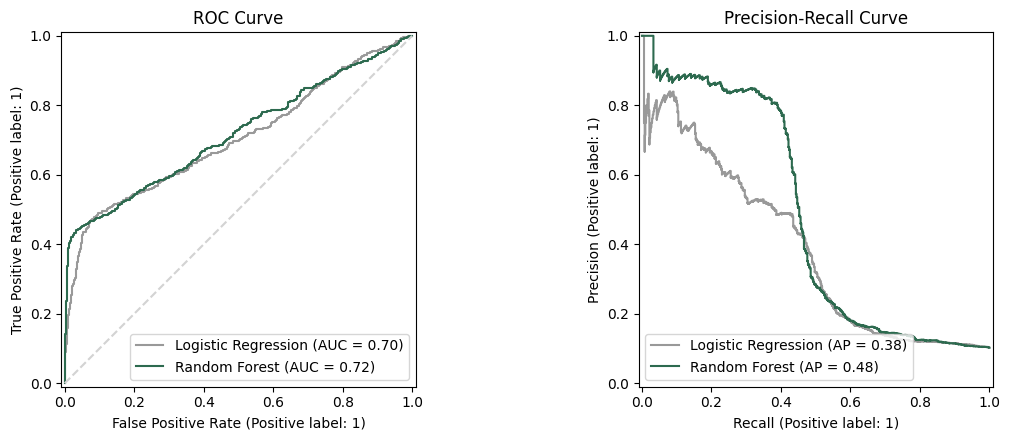

In [16]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

RocCurveDisplay.from_predictions(y_test, logreg_proba, name="Logistic Regression", ax=axes[0], color="#999999")
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=axes[0], color="#2D6A4F")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="lightgray")
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, logreg_proba, name="Logistic Regression", ax=axes[1], color="#999999")
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=axes[1], color="#2D6A4F")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


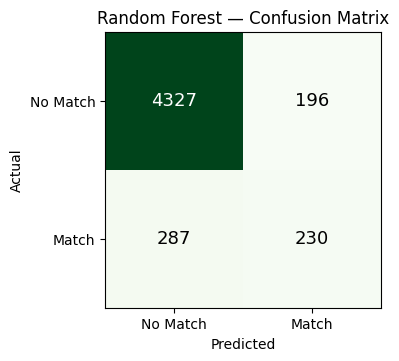

In [17]:
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No Match", "Match"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No Match", "Match"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Random Forest — Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
plt.tight_layout()
plt.show()


**Reading the results:** a ROC-AUC around 0.70–0.75 and PR-AUC well above the ~0.10 baseline
(the positive class rate) indicates the model has learned real signal without the task being
trivially easy — appropriate for a synthetic-but-realistic capstone dataset. The confusion matrix
shows recall on the minority (match) class is the harder problem, as expected with imbalance.

## 8. Feature Importance (Random Forest)

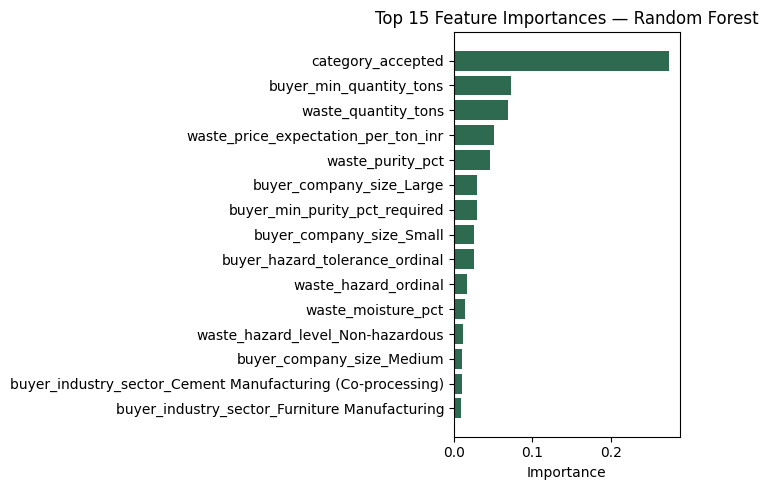

,feature,importance
9,category_accepted,0.274271
6,buyer_min_quantity_tons,0.072333
1,waste_quantity_tons,0.068675
4,waste_price_expectation_per_ton_inr,0.050980
2,waste_purity_pct,0.046305
91,buyer_company_size_Large,0.029265
7,buyer_min_purity_pct_required,0.029028
93,buyer_company_size_Small,0.025487
5,buyer_hazard_tolerance_ordinal,0.025322
0,waste_hazard_ordinal,0.017080


In [18]:
ohe = rf.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
feature_names = numeric_cols + list(ohe.get_feature_names_out(categorical_cols))
importances = rf.named_steps["clf"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(7, 5))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#2D6A4F")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

imp_df


## 9. Save the Trained Model
Saved as a single pipeline (preprocessing + classifier) so it can be reused directly on new waste/buyer pairs.

In [19]:
import joblib

joblib.dump(rf, "waste2worth_matching_model.joblib")
print("Model saved to waste2worth_matching_model.joblib")


Model saved to waste2worth_matching_model.joblib


### Using the saved model on new data
```python
import joblib
model = joblib.load("waste2worth_matching_model.joblib")

# new_pairs_df must have the same feature columns as X (see Section 3)
predicted_labels = model.predict(new_pairs_df)
match_probabilities = model.predict_proba(new_pairs_df)[:, 1]
```


In [23]:
import joblib

model = joblib.load("waste2worth_matching_model.joblib")

# new_pairs_df must have the same feature columns as X (see Section 3)
# For demonstration, we'll use X_test as new_pairs_df
new_pairs_df = X_test

predicted_labels = model.predict(new_pairs_df)
match_probabilities = model.predict_proba(new_pairs_df)[:, 1]

print("Predicted Labels:", predicted_labels[:5])
print("Match Probabilities:", match_probabilities[:5])

Predicted Labels: [0 0 0 1 0]
Match Probabilities: [0.33550799 0.37264593 0.34716421 0.78666979 0.31430883]


## Conclusion

This notebook trained and compared two models — Logistic Regression and Random Forest — for
predicting whether a waste listing is a good match for a candidate buyer industry, using the
synthetic `training_pairs.csv` dataset. The Random Forest model outperformed the linear baseline,
confirming that non-linear interactions between waste category, quantity, hazard tolerance, and
geography drive match likelihood — consistent with how the labels were constructed. For a
production Waste2Worth deployment, this pipeline would be retrained on real historical
transaction outcomes once the platform has accumulated enough completed deals.